In [24]:
import numpy as np
import torch
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Data generation
from src.data_generation.measurement_bias_world import simulate_measurement_bias_world

# Training utilities
from src.training.preprocessing import split_data, scale_data
from src.training.train_lr import train_logistic_regression
from src.training.train_mlp import train_mlp_model, plot

# Fairness metrics
from src.metrics.fairness import fairness_by_group, equal_opportunity_diff


In [26]:
df = simulate_measurement_bias_world(n_samples=10000, seed=SEED)
df.head()


,race,gender,age,glucose_measured,hba1c_measured,diabetes_label
0,0,0,66.807657,97.841564,5.524598,0
1,2,1,49.977538,75.150792,4.888884,0
2,1,1,41.819978,71.012752,5.361537,0
3,0,1,51.230187,93.368462,5.509108,0
4,0,0,44.494660,194.298253,7.718811,1


In [35]:
df.to_csv("df_measurement.csv", index=False)

print("Datasets saved!")

Datasets saved!


In [27]:
features = ["glucose_measured", "hba1c_measured", "age"]
target = "diabetes_label"

X_train, X_test, y_train, y_test = split_data(df, features, target)

X_train_s, X_test_s, scaler = scale_data(X_train, X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Prevalence:", y_train.mean())


Train size: 8000
Test size: 2000
Prevalence: 0.199375


In [28]:
X_train_s, X_test_s, scaler = scale_data(X_train, X_test)


In [29]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])
print("LR AUROC:", lr_results["AUROC"])


LR Accuracy: 0.995
LR AUROC: 0.999785342527278


Epoch 1/20: train_loss=0.0393, train_acc=98.84, val_loss=0.0216, val_acc=99.10
Epoch 2/20: train_loss=0.0146, train_acc=99.51, val_loss=0.0217, val_acc=99.25
Epoch 3/20: train_loss=0.0153, train_acc=99.55, val_loss=0.0152, val_acc=99.50
Epoch 4/20: train_loss=0.0137, train_acc=99.58, val_loss=0.0165, val_acc=99.40
Epoch 5/20: train_loss=0.0138, train_acc=99.58, val_loss=0.0170, val_acc=99.35
Epoch 6/20: train_loss=0.0134, train_acc=99.56, val_loss=0.0168, val_acc=99.55
Epoch 7/20: train_loss=0.0142, train_acc=99.54, val_loss=0.0152, val_acc=99.45
Epoch 8/20: train_loss=0.0132, train_acc=99.51, val_loss=0.0174, val_acc=99.40
Epoch 9/20: train_loss=0.0132, train_acc=99.59, val_loss=0.0171, val_acc=99.35
Epoch 10/20: train_loss=0.0134, train_acc=99.49, val_loss=0.0155, val_acc=99.45
Epoch 11/20: train_loss=0.0123, train_acc=99.58, val_loss=0.0222, val_acc=99.30
Epoch 12/20: train_loss=0.0134, train_acc=99.56, val_loss=0.0160, val_acc=99.45
Epoch 13/20: train_loss=0.0129, train_acc=99.53, 

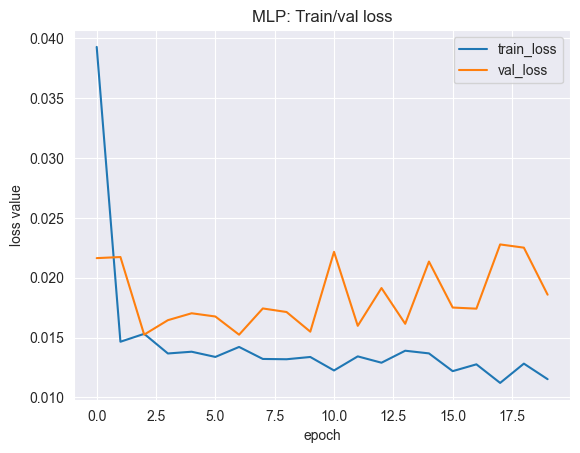

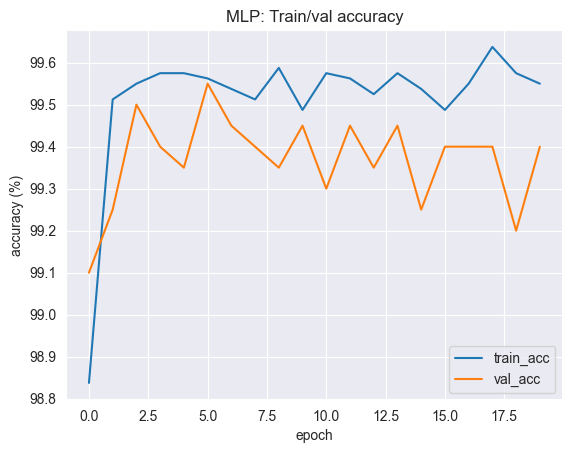

In [30]:
mlp_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=len(features),
    hidden_dim=32,
    n_epochs=20,
    lr=0.01
)

print("MLP Accuracy:", mlp_results["accuracy"])
print("MLP AUROC:", mlp_results["AUROC"])


In [32]:
df_test = df.loc[X_test.index].copy()

print("=== LR Fairness by Race ===")
lr_fair_race = fairness_by_group(y_test, lr_results["pred"], df_test["race"])
print(lr_fair_race)

print("\n=== LR Fairness by Gender ===")
lr_fair_gender = fairness_by_group(y_test, lr_results["pred"], df_test["gender"])
print(lr_fair_gender)

LR_EO_race = equal_opportunity_diff(lr_fair_race)
LR_EO_gender = equal_opportunity_diff(lr_fair_gender)



print("\n=== MLP Fairness by Race ===")
mlp_fair_race = fairness_by_group(y_test, mlp_results["pred"], df_test["race"])
print(mlp_fair_race)

print("\n=== MLP Fairness by Gender ===")
mlp_fair_gender = fairness_by_group(y_test, mlp_results["pred"], df_test["gender"])
print(mlp_fair_gender)

MLP_EO_race   = equal_opportunity_diff(mlp_fair_race)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)


=== LR Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.000000  0.017167  0.982833  1.000000
1  0.010025  0.022727  0.977273  0.989975
2  0.000000  0.000000  1.000000  1.000000

=== LR Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.002532  0.011429  0.988571  0.997468
1  0.002387  0.020305  0.979695  0.997613

=== MLP Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.001018  0.012876  0.987124  0.998982
1  0.015038  0.022727  0.977273  0.984962
2  0.000000  0.000000  1.000000  1.000000

=== MLP Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.005063  0.011429  0.988571  0.994937
1  0.003580  0.015228  0.984772  0.996420


In [33]:
results_measurement_bias = {
    "world_name": "MeasurementBias",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,

    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

results_measurement_bias


{'world_name': 'MeasurementBias',
 'LR_accuracy': 0.995,
 'LR_AUROC': 0.999785342527278,
 'LR_EO_race': 0.022727272727272707,
 'LR_EO_gender': 0.008875997099347277,
 'MLP_accuracy': np.float64(0.994),
 'MLP_AUROC': 0.9995904995904996,
 'MLP_EO_race': 0.022727272727272707,
 'MLP_EO_gender': 0.0037998549673676774}

In [34]:
results_measurement_bias = {
    "world_name": "MeasurementBias",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,
    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

json.dump(results_measurement_bias, open("results_measurement.json", "w"), indent=4)
print("Saved MeasurementBias world → results_measurement.json")


Saved MeasurementBias world → results_measurement.json
